In [1]:
import os
import cv2, tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from keras.models import Sequential
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
image_dir = 'input/trainOG'
train_folders = os.listdir(image_dir)
Sx = 224
Sy = 224
epocas = 20
train_size = 100
test_size = 20

In [3]:
print(f"Min files in a folder: {min([len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))]) for fldr in train_folders])}")
total_images = sum(
    len([f for f in os.listdir(os.path.join(image_dir, fldr)) if os.path.isfile(os.path.join(image_dir, fldr, f))])
    for fldr in train_folders
)
print(f"Total images: {total_images}")

Min files in a folder: 101
Total images: 7614


25it [00:00, 131.56it/s]


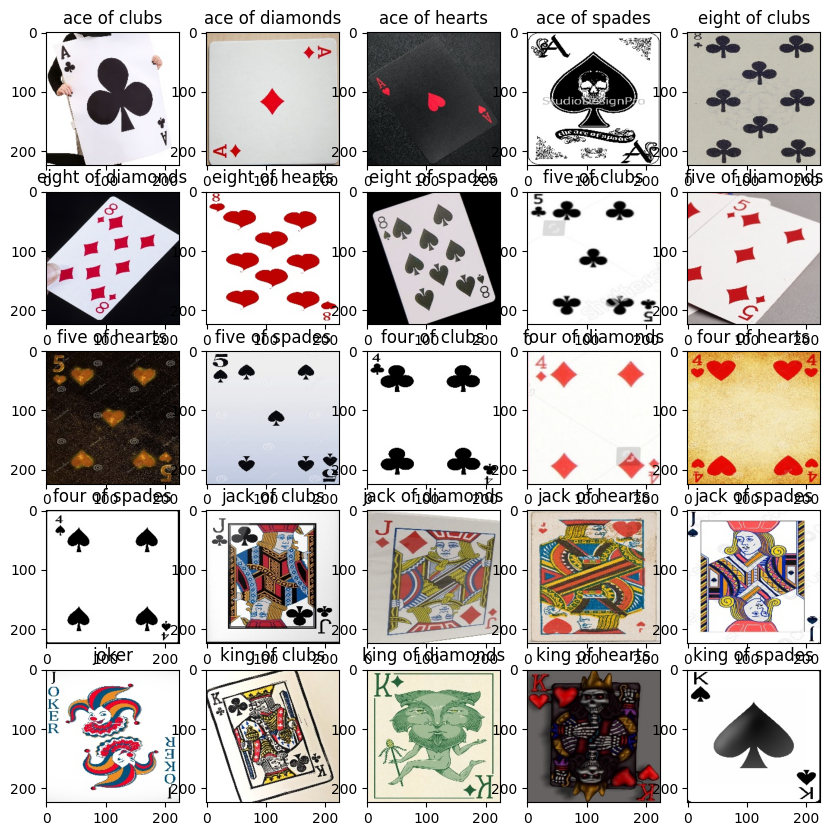

In [4]:
def exploreData (folders) :
    plt.figure(figsize=(10,10))
    for i,fol in tqdm.tqdm(enumerate(folders[:25])) :
        plt.subplot(5,5 ,i+1)
        image = os.listdir(os.path.join(image_dir,fol))[0]
        imgPath = os.path.join(image_dir,fol,image)
        img = cv2.imread(imgPath)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        plt.title(fol)
        plt.imshow(imgRGB)
    plt.show()
exploreData(train_folders)

In [4]:
x_test_RGB = []
y_test_RGB = []
x_valid_RGB = []
y_valid_RGB = []
x_train_RGB = []
y_train_RGB = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[:test_size]
    test_images = images_in_folder[test_size:]
    train_images = images_in_folder[train_size:]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_test_RGB.append(imgRGB)
        y_test_RGB.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_valid_RGB.append(imgRGB)
        y_valid_RGB.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgRGB = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
        imgRGB = cv2.resize(imgRGB, (Sx,Sy))
        x_train_RGB.append(imgRGB)
        y_train_RGB.append(folder)

x_test_RGB = np.array(x_test_RGB)
x_valid_RGB = np.array(x_valid_RGB)
x_train_RGB = np.array(x_train_RGB)

x_test_RGB = x_test_RGB.astype('float32') / 255.0
x_valid_RGB = x_valid_RGB.astype('float32') / 255.0
x_train_RGB = x_train_RGB.astype('float32') / 255.0

x_test_RGB = x_test_RGB.reshape(-1,Sx,Sy,3)
x_valid_RGB = x_valid_RGB.reshape(-1,Sx,Sy,3)
x_train_RGB = x_train_RGB.reshape(-1,Sx,Sy,3)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_RGB = [categories[i] for i in y_train_RGB]
y_valid_RGB = [categories[i] for i in y_valid_RGB]
y_test_RGB = [categories[i] for i in y_test_RGB]

y_train_RGB = to_categorical(y_train_RGB)
y_valid_RGB = to_categorical(y_valid_RGB)
y_test_RGB = to_categorical(y_test_RGB)

100%|██████████| 53/53 [00:07<00:00,  7.56it/s]


In [ ]:
x_test_ByN = []
y_test_ByN = []
x_valid_ByN = []
y_valid_ByN = []
x_train_ByN = []
y_train_ByN = []

random.seed(42)

for folder in tqdm.tqdm(train_folders):
    folder_path = os.path.join(image_dir, folder)
    images_in_folder = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random.shuffle(images_in_folder)

    valid_images = images_in_folder[-test_size:]
    test_images = images_in_folder[:test_size]
    train_images = images_in_folder[:train_size]

    for img_path in test_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_test_ByN.append(imgByN)
        y_test_ByN.append(folder)

    for img_path in valid_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_valid_ByN.append(imgByN)
        y_valid_ByN.append(folder)

    for img_path in train_images:
        img = cv2.imread(img_path)
        imgByN = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
        imgByN = cv2.resize(imgByN, (Sx,Sy))
        x_train_ByN.append(imgByN)
        y_train_ByN.append(folder)

x_test_ByN = np.array(x_test_ByN)
x_valid_ByN = np.array(x_valid_ByN)
x_train_ByN = np.array(x_train_ByN)

x_test_ByN = x_test_ByN.astype('float32') / 255.0
x_valid_ByN = x_valid_ByN.astype('float32') / 255.0
x_train_ByN = x_train_ByN.astype('float32') / 255.0

x_test_ByN = x_test_ByN.reshape(-1,Sx,Sy,1)
x_valid_ByN = x_valid_ByN.reshape(-1,Sx,Sy,1)
x_train_ByN = x_train_ByN.reshape(-1,Sx,Sy,1)

df = pd.read_csv('input/cards.csv')
category_labels = df.labels.value_counts().index
categories = {}
for index,cat in enumerate(category_labels) :
  categories[cat]=index

y_train_ByN = [categories[i] for i in y_train_ByN]
y_valid_ByN = [categories[i] for i in y_valid_ByN]
y_test_ByN = [categories[i] for i in y_test_ByN]

y_train_ByN = to_categorical(y_train_ByN)
y_valid_ByN = to_categorical(y_valid_ByN)
y_test_ByN = to_categorical(y_test_ByN)

100%|██████████| 53/53 [00:04<00:00, 13.01it/s]


In [7]:
modelo_1 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_metrics = modelo_1.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 11s 65ms/step - loss: 7.8193 - accuracy: 0.0168 - val_loss: 3.9694 - val_accuracy: 0.0132
Epoch 2/20
73/73 [==============================] - 4s 52ms/step - loss: 3.9582 - accuracy: 0.0340 - val_loss: 3.9704 - val_accuracy: 0.0189
Epoch 3/20
73/73 [==============================] - 4s 52ms/step - loss: 3.9486 - accuracy: 0.0404 - val_loss: 3.9759 - val_accuracy: 0.0377
Epoch 4/20
73/73 [==============================] - 4s 52ms/step - loss: 3.8205 - accuracy: 0.0792 - val_loss: 3.7404 - val_accuracy: 0.0981
Epoch 5/20
73/73 [==============================] - 4s 52ms/step - loss: 3.0840 - accuracy: 0.2190 - val_loss: 3.2487 - val_accuracy: 0.1906
Epoch 6/20
73/73 [==============================] - 4s 52ms/step - loss: 2.0444 - accuracy: 0.4729 - val_loss: 3.0399 - val_accuracy: 0.2575
Epoch 7/20
73/73 [==============================] - 4s 53ms/step - loss: 1.2236 - accuracy: 0.6846 - val_loss: 3.0372 - val_accuracy: 0.3236
Epoch 8/20
7

In [8]:
modelo_1.evaluate(x_test_RGB, y_test_RGB)

206/206 [==============================] - 3s 14ms/step - loss: 4.0799 - accuracy: 0.5678


[4.079858303070068, 0.5677940249443054]

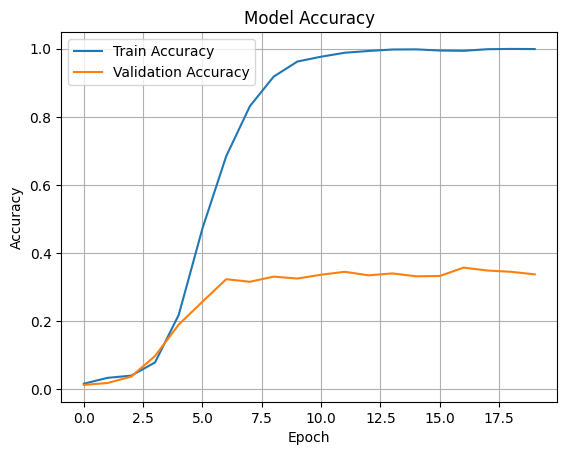

In [9]:
plt.plot(modelo_1_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
modelo_1_ByN = Sequential([
    Input(shape=(Sx,Sy,1)),
    Conv2D(32 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_1_ByN.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_1_ByN_metrics = modelo_1_ByN.fit(x_train_ByN,y_train_ByN,validation_data= (x_valid_ByN,y_valid_ByN), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 5s 59ms/step - loss: 7.7939 - accuracy: 0.0306 - val_loss: 3.9569 - val_accuracy: 0.0415
Epoch 2/20
73/73 [==============================] - 4s 55ms/step - loss: 3.8233 - accuracy: 0.0641 - val_loss: 3.9846 - val_accuracy: 0.0528
Epoch 3/20
73/73 [==============================] - 4s 51ms/step - loss: 3.5083 - accuracy: 0.1222 - val_loss: 3.8500 - val_accuracy: 0.0811
Epoch 4/20
73/73 [==============================] - 4s 50ms/step - loss: 2.9702 - accuracy: 0.2345 - val_loss: 3.6147 - val_accuracy: 0.1123
Epoch 5/20
73/73 [==============================] - 4s 49ms/step - loss: 2.4316 - accuracy: 0.3429 - val_loss: 3.3186 - val_accuracy: 0.1726
Epoch 6/20
73/73 [==============================] - 4s 50ms/step - loss: 1.9179 - accuracy: 0.4733 - val_loss: 3.3520 - val_accuracy: 0.1764
Epoch 7/20
73/73 [==============================] - 4s 49ms/step - loss: 1.4696 - accuracy: 0.6106 - val_loss: 3.3459 - val_accuracy: 0.2113
Epoch 8/20
73

In [11]:
modelo_1_ByN.evaluate(x_test_ByN, y_test_ByN)

206/206 [==============================] - 2s 11ms/step - loss: 4.4641 - accuracy: 0.4878


[4.464135646820068, 0.4878123104572296]

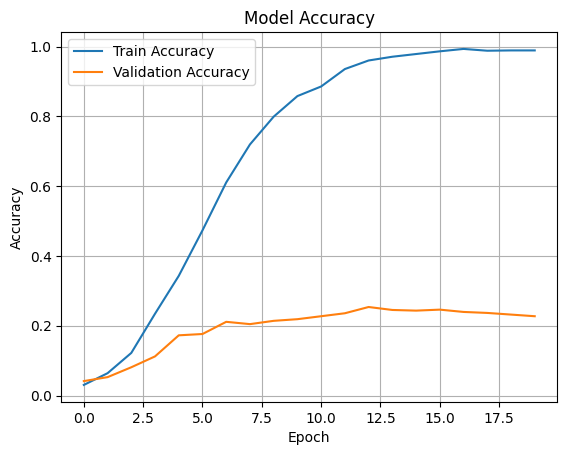

In [12]:
plt.plot(modelo_1_ByN_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_1_ByN_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
modelo_VGG = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    Conv2D(256 , (3,3) , activation='relu'),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    Conv2D(512 , (3,3) , activation='relu'),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_metrics = modelo_VGG.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = 5)

Epoch 1/5
73/73 [==============================] - 38s 506ms/step - loss: 4.0175 - accuracy: 0.0219 - val_loss: 4.0418 - val_accuracy: 0.0189
Epoch 2/5
73/73 [==============================] - 31s 431ms/step - loss: 3.9120 - accuracy: 0.0284 - val_loss: 4.0359 - val_accuracy: 0.0189
Epoch 3/5
73/73 [==============================] - 31s 428ms/step - loss: 3.9007 - accuracy: 0.0327 - val_loss: 4.0337 - val_accuracy: 0.0189
Epoch 4/5
73/73 [==============================] - 32s 442ms/step - loss: 3.8986 - accuracy: 0.0258 - val_loss: 4.0536 - val_accuracy: 0.0189
Epoch 5/5
73/73 [==============================] - 31s 420ms/step - loss: 3.8985 - accuracy: 0.0349 - val_loss: 4.0331 - val_accuracy: 0.0189


In [9]:
modelo_VGG_2 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG_2.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_2_metrics = modelo_VGG_2.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 14s 188ms/step - loss: 3.9462 - accuracy: 0.0370 - val_loss: 3.8812 - val_accuracy: 0.0613
Epoch 2/20
73/73 [==============================] - 14s 191ms/step - loss: 3.1231 - accuracy: 0.2147 - val_loss: 2.8805 - val_accuracy: 0.2481
Epoch 3/20
73/73 [==============================] - 13s 178ms/step - loss: 2.2577 - accuracy: 0.3963 - val_loss: 2.4518 - val_accuracy: 0.3547
Epoch 4/20
73/73 [==============================] - 13s 177ms/step - loss: 1.6321 - accuracy: 0.5529 - val_loss: 2.4048 - val_accuracy: 0.3972
Epoch 5/20
73/73 [==============================] - 13s 178ms/step - loss: 1.1333 - accuracy: 0.6756 - val_loss: 2.2369 - val_accuracy: 0.4472
Epoch 6/20
73/73 [==============================] - 14s 186ms/step - loss: 0.7787 - accuracy: 0.7806 - val_loss: 2.7960 - val_accuracy: 0.4962
Epoch 7/20
73/73 [==============================] - 13s 181ms/step - loss: 0.4623 - accuracy: 0.8756 - val_loss: 3.0721 - val_accuracy: 0.4887

In [10]:
modelo_VGG_2.evaluate(x_test_RGB, y_test_RGB)

206/206 [==============================] - 9s 42ms/step - loss: 3.6671 - accuracy: 0.7029


[3.6670987606048584, 0.7029250264167786]

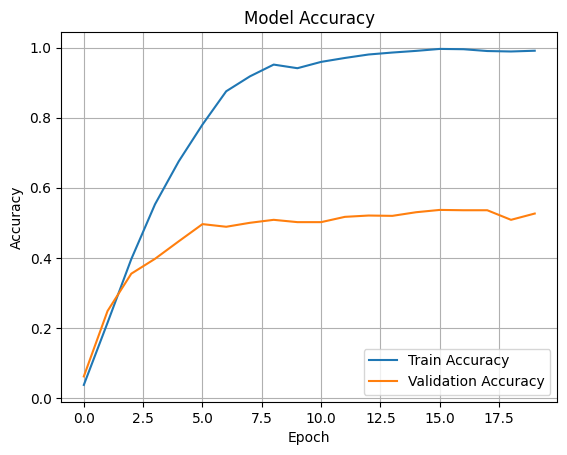

In [12]:
plt.plot(modelo_VGG_2_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_2_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
modelo_VGG_2_ByN = Sequential([
    Input(shape=(Sx,Sy,1)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG_2_ByN.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_2_ByN_metrics = modelo_VGG_2_ByN.fit(x_train_ByN,y_train_ByN,validation_data= (x_valid_ByN,y_valid_ByN), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 15s 202ms/step - loss: 3.9527 - accuracy: 0.0275 - val_loss: 4.0245 - val_accuracy: 0.0189
Epoch 2/20
73/73 [==============================] - 12s 170ms/step - loss: 3.8821 - accuracy: 0.0422 - val_loss: 3.9639 - val_accuracy: 0.0623
Epoch 3/20
73/73 [==============================] - 13s 173ms/step - loss: 3.3240 - accuracy: 0.1704 - val_loss: 3.1374 - val_accuracy: 0.1934
Epoch 4/20
73/73 [==============================] - 13s 174ms/step - loss: 2.4738 - accuracy: 0.3309 - val_loss: 2.5637 - val_accuracy: 0.3217
Epoch 5/20
73/73 [==============================] - 14s 193ms/step - loss: 1.8485 - accuracy: 0.4750 - val_loss: 2.2756 - val_accuracy: 0.4066
Epoch 6/20
73/73 [==============================] - 12s 171ms/step - loss: 1.3688 - accuracy: 0.6192 - val_loss: 2.3955 - val_accuracy: 0.4594
Epoch 7/20
73/73 [==============================] - 12s 170ms/step - loss: 0.9903 - accuracy: 0.7190 - val_loss: 2.6088 - val_accuracy: 0.4811

In [14]:
modelo_VGG_2_ByN.evaluate(x_test_ByN, y_test_ByN)

206/206 [==============================] - 8s 39ms/step - loss: 3.5973 - accuracy: 0.6892


[3.597334861755371, 0.6892138719558716]

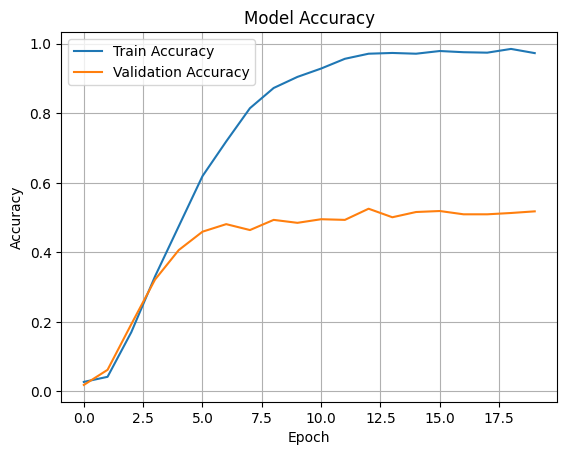

In [15]:
plt.plot(modelo_VGG_2_ByN_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_2_ByN_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
modelo_VGG_3 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG_3.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_3_metrics = modelo_VGG_3.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 12s 160ms/step - loss: 4.0002 - accuracy: 0.0267 - val_loss: 3.9584 - val_accuracy: 0.0189
Epoch 2/20
73/73 [==============================] - 14s 186ms/step - loss: 3.7972 - accuracy: 0.0680 - val_loss: 3.6311 - val_accuracy: 0.1340
Epoch 3/20
73/73 [==============================] - 17s 238ms/step - loss: 3.2889 - accuracy: 0.1652 - val_loss: 3.0055 - val_accuracy: 0.2217
Epoch 4/20
73/73 [==============================] - 25s 344ms/step - loss: 2.8067 - accuracy: 0.2341 - val_loss: 2.6311 - val_accuracy: 0.2792
Epoch 5/20
73/73 [==============================] - 22s 305ms/step - loss: 2.5201 - accuracy: 0.3046 - val_loss: 2.3724 - val_accuracy: 0.3198
Epoch 6/20
73/73 [==============================] - 17s 228ms/step - loss: 2.2975 - accuracy: 0.3468 - val_loss: 2.3027 - val_accuracy: 0.3349
Epoch 7/20
73/73 [==============================] - 14s 194ms/step - loss: 2.1097 - accuracy: 0.3933 - val_loss: 2.1420 - val_accuracy: 0.4226

In [15]:
modelo_VGG_3.evaluate(x_test_RGB, y_test_RGB)

206/206 [==============================] - 9s 43ms/step - loss: 1.3025 - accuracy: 0.7153


[1.3025354146957397, 0.7152650952339172]

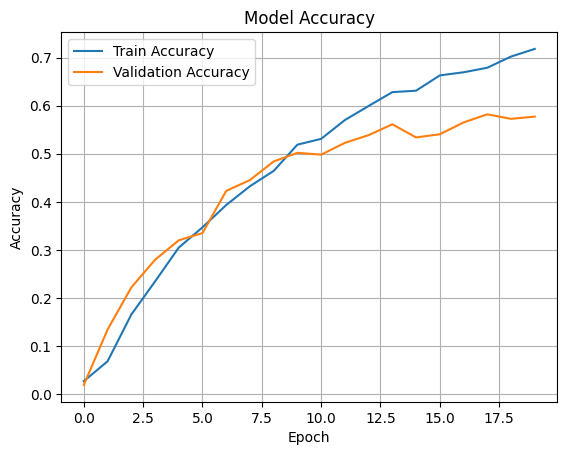

In [16]:
plt.plot(modelo_VGG_3_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_3_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
modelo_VGG_4 = Sequential([
    Input(shape=(Sx,Sy,3)),
    Conv2D(64 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(256 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(512 , (3,3) , activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dropout(0.5),
    Dense(256, activation = 'relu'),
    Dropout(0.5),
    Dense(128, activation = 'relu'),
    Dense(64 , activation = 'relu'),
    Dense(53 , activation = 'softmax')
])
modelo_VGG_4.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics=['accuracy'])
modelo_VGG_4_metrics = modelo_VGG_4.fit(x_train_RGB,y_train_RGB,validation_data= (x_valid_RGB,y_valid_RGB), epochs = epocas)

Epoch 1/20
73/73 [==============================] - 40s 332ms/step - loss: 3.9716 - accuracy: 0.0229 - val_loss: 3.9985 - val_accuracy: 0.0189
Epoch 2/20
73/73 [==============================] - 19s 266ms/step - loss: 3.8729 - accuracy: 0.0359 - val_loss: 4.1368 - val_accuracy: 0.0292
Epoch 3/20
73/73 [==============================] - 17s 239ms/step - loss: 3.6294 - accuracy: 0.0925 - val_loss: 3.6825 - val_accuracy: 0.1104
Epoch 4/20
73/73 [==============================] - 14s 194ms/step - loss: 3.1573 - accuracy: 0.1698 - val_loss: 3.3876 - val_accuracy: 0.1462
Epoch 5/20
73/73 [==============================] - 16s 217ms/step - loss: 2.7863 - accuracy: 0.2156 - val_loss: 3.0975 - val_accuracy: 0.1783
Epoch 6/20
73/73 [==============================] - 16s 219ms/step - loss: 2.4973 - accuracy: 0.2822 - val_loss: 2.8737 - val_accuracy: 0.2717
Epoch 7/20
73/73 [==============================] - 16s 221ms/step - loss: 2.1985 - accuracy: 0.3505 - val_loss: 2.5013 - val_accuracy: 0.3887

In [6]:
modelo_VGG_4.evaluate(x_test_RGB, y_test_RGB)

205/205 [==============================] - 12s 59ms/step - loss: 1.5493 - accuracy: 0.7182


[1.5493272542953491, 0.7181873917579651]

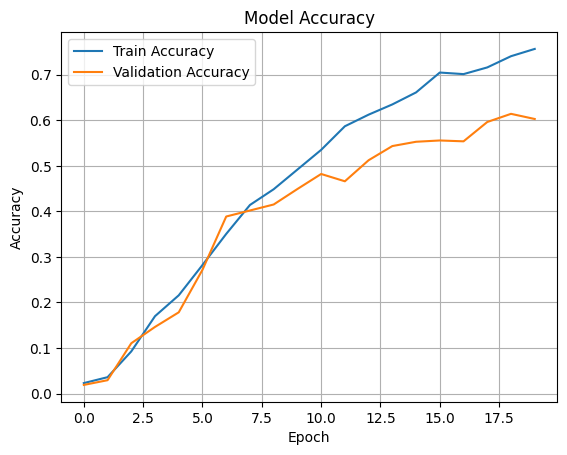

In [7]:
plt.plot(modelo_VGG_4_metrics.history['accuracy'], label='Train Accuracy')
plt.plot(modelo_VGG_4_metrics.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

34/34 [==============================] - 2s 57ms/step


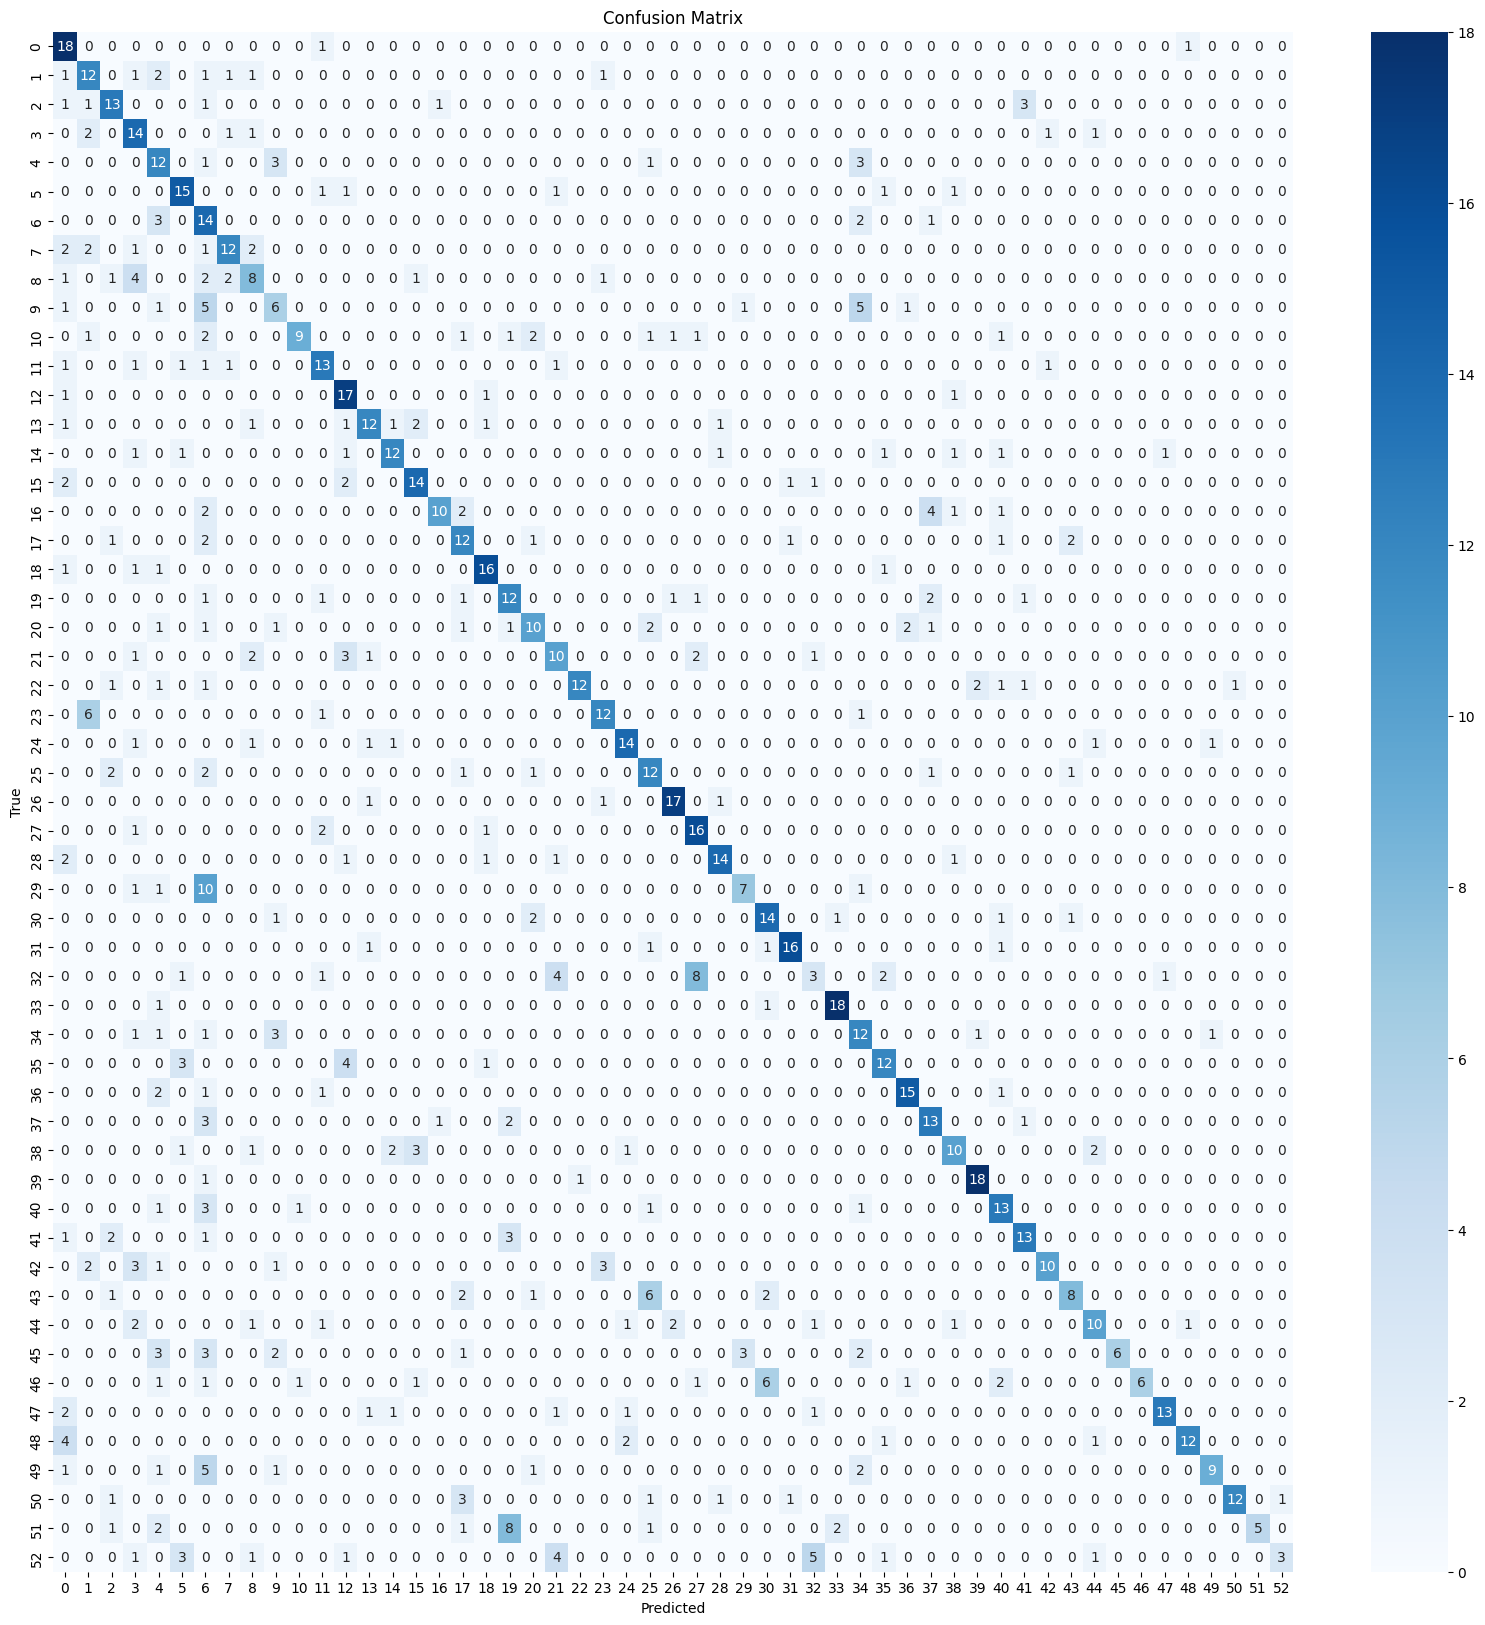

Most problematic classes (names): ['seven of clubs', 'eight of clubs', 'three of hearts', 'king of hearts', 'seven of diamonds', 'jack of diamonds', 'queen of hearts', 'six of hearts', 'queen of clubs', 'joker']
Their accuracies: [0.15 0.15 0.25 0.3  0.3  0.3  0.35 0.4  0.4  0.45]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred = modelo_VGG_4.predict(x_valid_RGB)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_valid_RGB, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(53), 
            yticklabels=range(53))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Find most problematic classes
class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
worst_classes = np.argsort(class_accuracy)[:10]  # Top 10 worst performing classes
# Diccionario inverso: id de clase -> nombre de clase
id_to_class = {v: k for k, v in categories.items()}

# Ejemplo de uso: mostrar los nombres de las clases más problemáticas
print("Most problematic classes (names):", [id_to_class[i] for i in worst_classes])
print("Their accuracies:", class_accuracy[worst_classes])
